In [1]:
# Imports and Config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.2

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

In [5]:
# Load Data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Feature Engineering

# Fix TotalCharges (loaded as string due to blank values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID — not a feature
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# New features
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['HasMultipleServices'] = (
    (df['PhoneService'] == 'Yes').astype(int) +
    (df['InternetService'] != 'No').astype(int) +
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int)
)

# Encode all remaining categoricals
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)
df.head()

gender                   int64
SeniorCitizen            int64
Partner                  int64
Dependents               int64
tenure                   int64
PhoneService             int64
MultipleLines            int64
InternetService          int64
OnlineSecurity           int64
OnlineBackup             int64
DeviceProtection         int64
TechSupport              int64
StreamingTV              int64
StreamingMovies          int64
Contract                 int64
PaperlessBilling         int64
PaymentMethod            int64
MonthlyCharges         float64
TotalCharges           float64
Churn                    int64
ChargesPerMonth        float64
HasMultipleServices      int64
dtype: object


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,HasMultipleServices
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,1,2,29.85,29.85,0,14.925000,1
1,1,0,0,0,34,1,0,0,2,0,...,0,0,1,0,3,56.95,1889.50,0,53.985714,3
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,36.050000,3
3,1,0,0,0,45,0,1,0,2,0,...,0,0,1,0,0,42.30,1840.75,0,40.016304,3
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,50.550000,2


In [9]:
# Train/Test Split
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')

Train: (5634, 21) | Test: (1409, 21)
Churn rate — Train: 26.54% | Test: 26.54%


In [11]:
# Model Comparison

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    results[name] = scores
    print(f'{name:25s} — AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       — AUC: 0.8467 ± 0.0110
Random Forest             — AUC: 0.8258 ± 0.0101
XGBoost                   — AUC: 0.8238 ± 0.0121
LightGBM                  — AUC: 0.8346 ± 0.0064


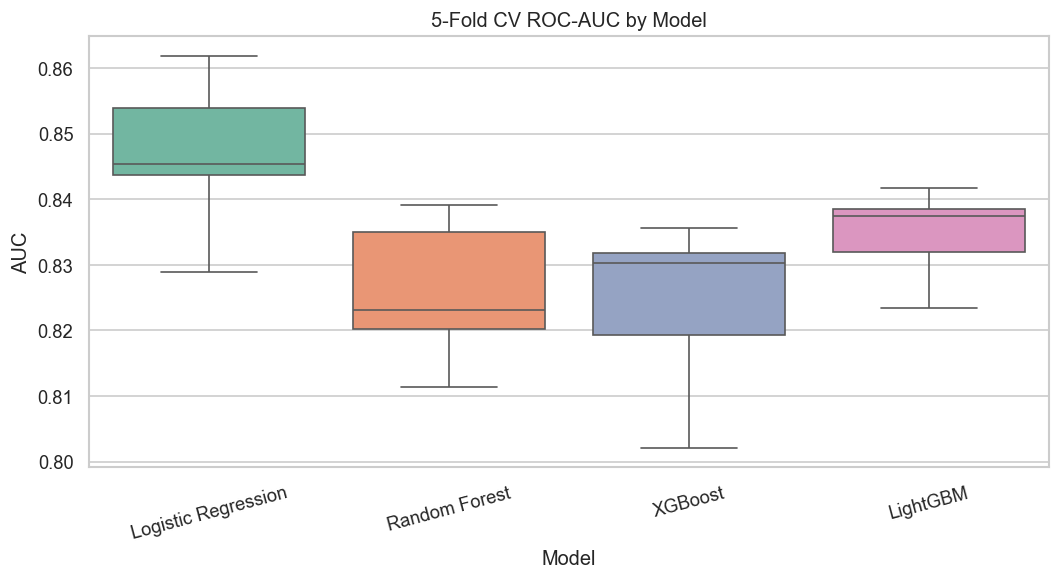

In [17]:
# Plotting CV Results

results_df = pd.DataFrame(results).melt(var_name='Model', value_name='AUC')

plt.figure(figsize=(9, 5))
sns.boxplot(data=results_df, x='Model', y='AUC', palette='Set2')
plt.title('5-Fold CV ROC-AUC by Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png')
plt.show()

In [19]:
# Train Best Model and Evaluate

# Train best model — Logistic Regression had highest CV AUC
best_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8474


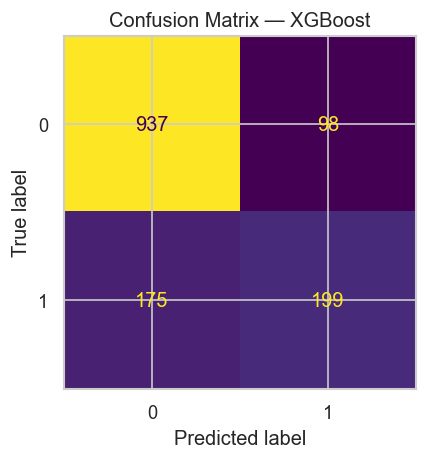

In [25]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png')
plt.show()

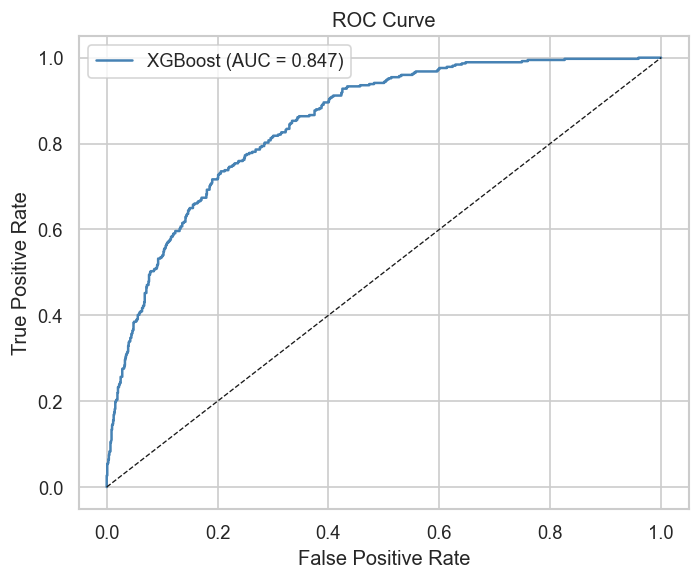

In [27]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.3f})', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png')
plt.show()

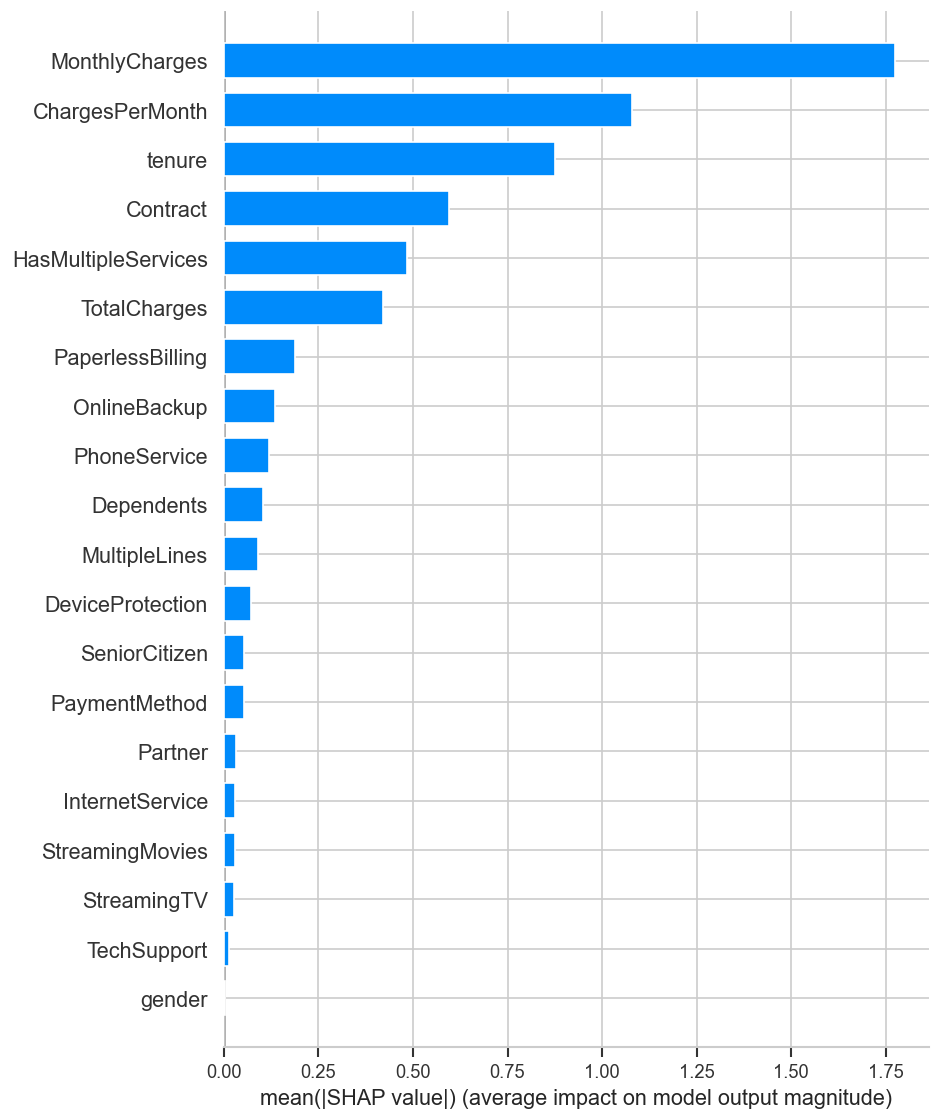

In [31]:
# SHAP Feature Importance (Global)

explainer = shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png')
plt.show()

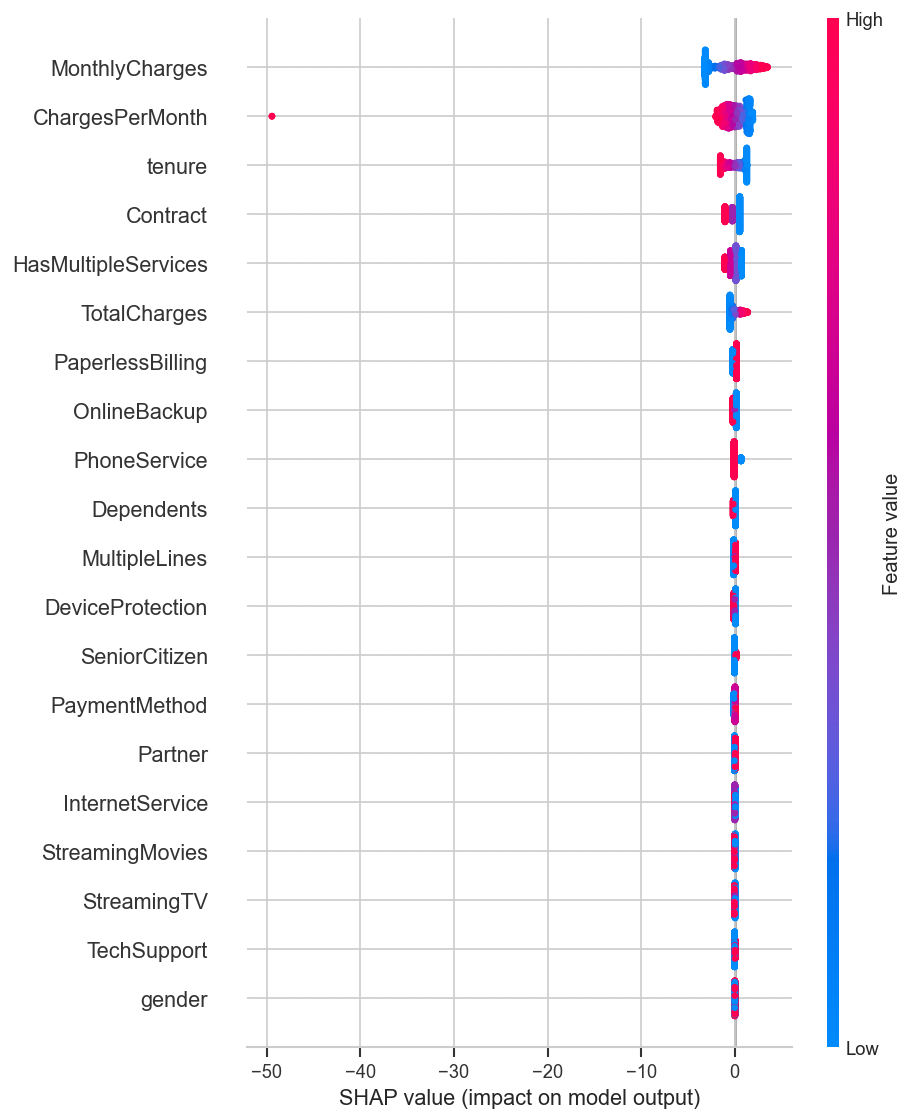

In [33]:
# SHAP Beeswarm

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png')
plt.show()

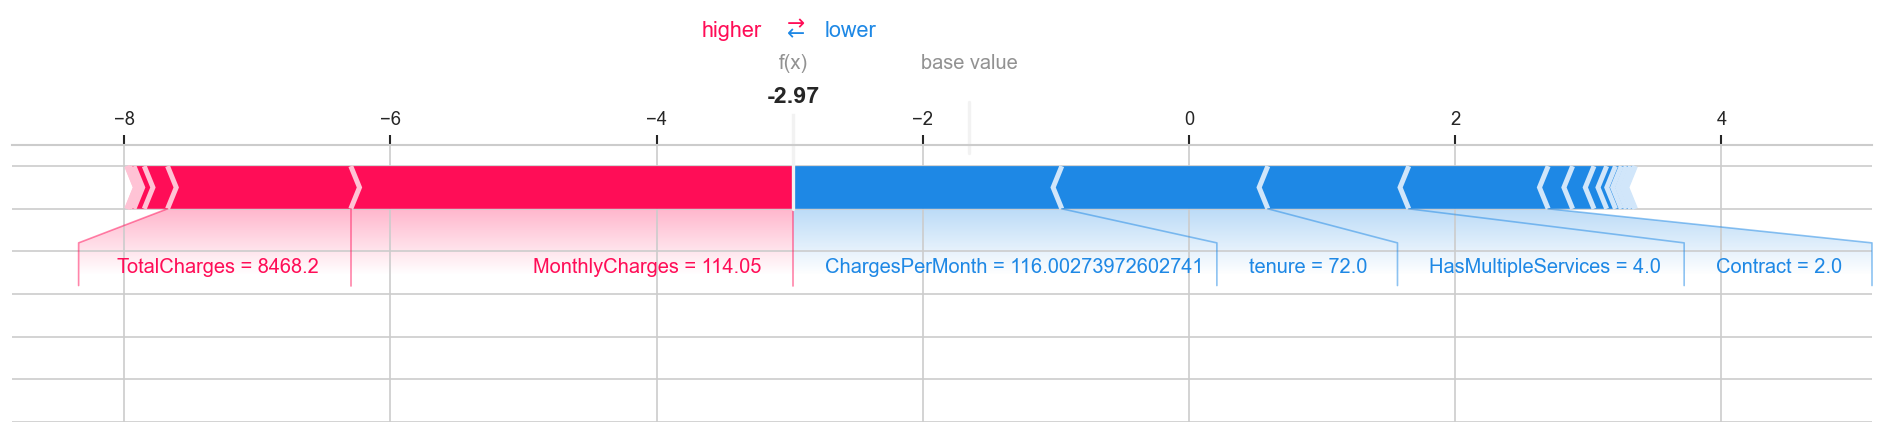

<Figure size 768x576 with 0 Axes>

In [35]:
idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)
plt.tight_layout()
plt.savefig('../outputs/shap_force_plot.png')
plt.show()

In [39]:
import joblib
import os

joblib.dump(best_model, '../models/lr_churn_model.pkl')
print('Model saved to ../models/lr_churn_model.pkl')

Model saved to ../models/lr_churn_model.pkl
